In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

Angulo del perihelio por vuelta:
  Vuelta 1 : theta_perihelio = 0.0 grados
  Vuelta 2 : theta_perihelio = 20.81 grados
  Vuelta 3 : theta_perihelio = 41.62 grados
  Vuelta 4 : theta_perihelio = 62.15 grados


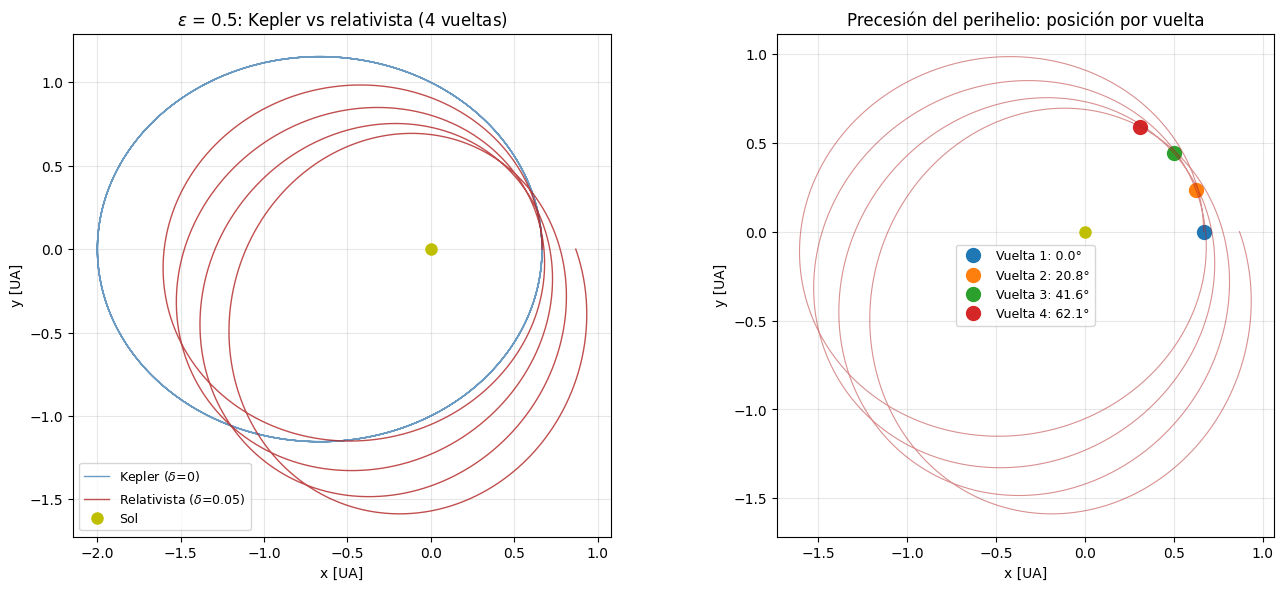

In [3]:
alpha= 1.0

delta_rel = 0.05

eps_demo = 0.5
estado_inicial_demo = [(1 + eps_demo) / alpha, 0.0]

ti_demo = 0.0
tf_demo = 4 * 2 * np.pi
lt_demo = np.linspace(ti_demo, tf_demo, 5000)

sol_kepler = solve_ivp(derivadas, [ti_demo, tf_demo], estado_inicial_demo,
                       t_eval=lt_demo, args=(alpha, 0.0),
                       rtol=1e-9, atol=1e-11)
sol_rel    = solve_ivp(derivadas, [ti_demo, tf_demo], estado_inicial_demo,
                       t_eval=lt_demo, args=(alpha, delta_rel),
                       rtol=1e-9, atol=1e-11)

xk, yk = a_cartesiano(sol_kepler.t, sol_kepler.y[0])
xr, yr = a_cartesiano(sol_rel.t,    sol_rel.y[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_aspect(1.0)
ax.set_title(r'$\varepsilon$ = 0.5: Kepler vs relativista (4 vueltas)')
ax.plot(xk, yk, 'steelblue', lw=1.0, label=r'Kepler ($\delta$=0)', alpha=0.8)
ax.plot(xr, yr, 'firebrick',  lw=1.0, label=r'Relativista ($\delta$=0.05)', alpha=0.8)
ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_title('Precesión del perihelio: posición por vuelta')

r_rel     = 1.0 / sol_rel.y[0]
thetas_r  = sol_rel.t
total_pts = len(thetas_r)
pts_por_vuelta = total_pts // 4

print('Angulo del perihelio por vuelta:')
for vuelta in range(4):
    ini = vuelta * pts_por_vuelta
    fin = min((vuelta + 1) * pts_por_vuelta, total_pts - 1)

    segmento_r = r_rel[ini:fin]
    idx_min    = np.argmin(segmento_r) + ini

    theta_peri = thetas_r[idx_min]
    r_peri     = r_rel[idx_min]

    xp = r_peri * np.cos(theta_peri)
    yp = r_peri * np.sin(theta_peri)

    ang_mod = np.degrees(theta_peri % (2 * np.pi))
    print('  Vuelta', vuelta+1, ': theta_perihelio =', round(ang_mod, 2), 'grados')

    ax2.plot(xp, yp, 'o', ms=10,
             label='Vuelta ' + str(vuelta+1) + ': ' + str(round(ang_mod, 1)) + '°')

ax2.plot(xr, yr, 'firebrick', lw=0.8, alpha=0.5)
ax2.plot(0, 0, 'yo', ms=8, zorder=5)
ax2.set_aspect(1.0)
ax2.legend(fontsize=9)
ax2.set_xlabel('x [UA]')
ax2.set_ylabel('y [UA]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'graficos\figura_6_kepler_vs_relativista.png', dpi=120, bbox_inches='tight')
plt.show()